In [44]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm

from sklearn.preprocessing import StandardScaler

import random
from datetime import datetime
from scipy.stats import skewnorm
from IPython.display import clear_output
import re


DEBUG = True

In [2]:
#!pip install networkx

<Axes: >

2024-03-07 17:00:00


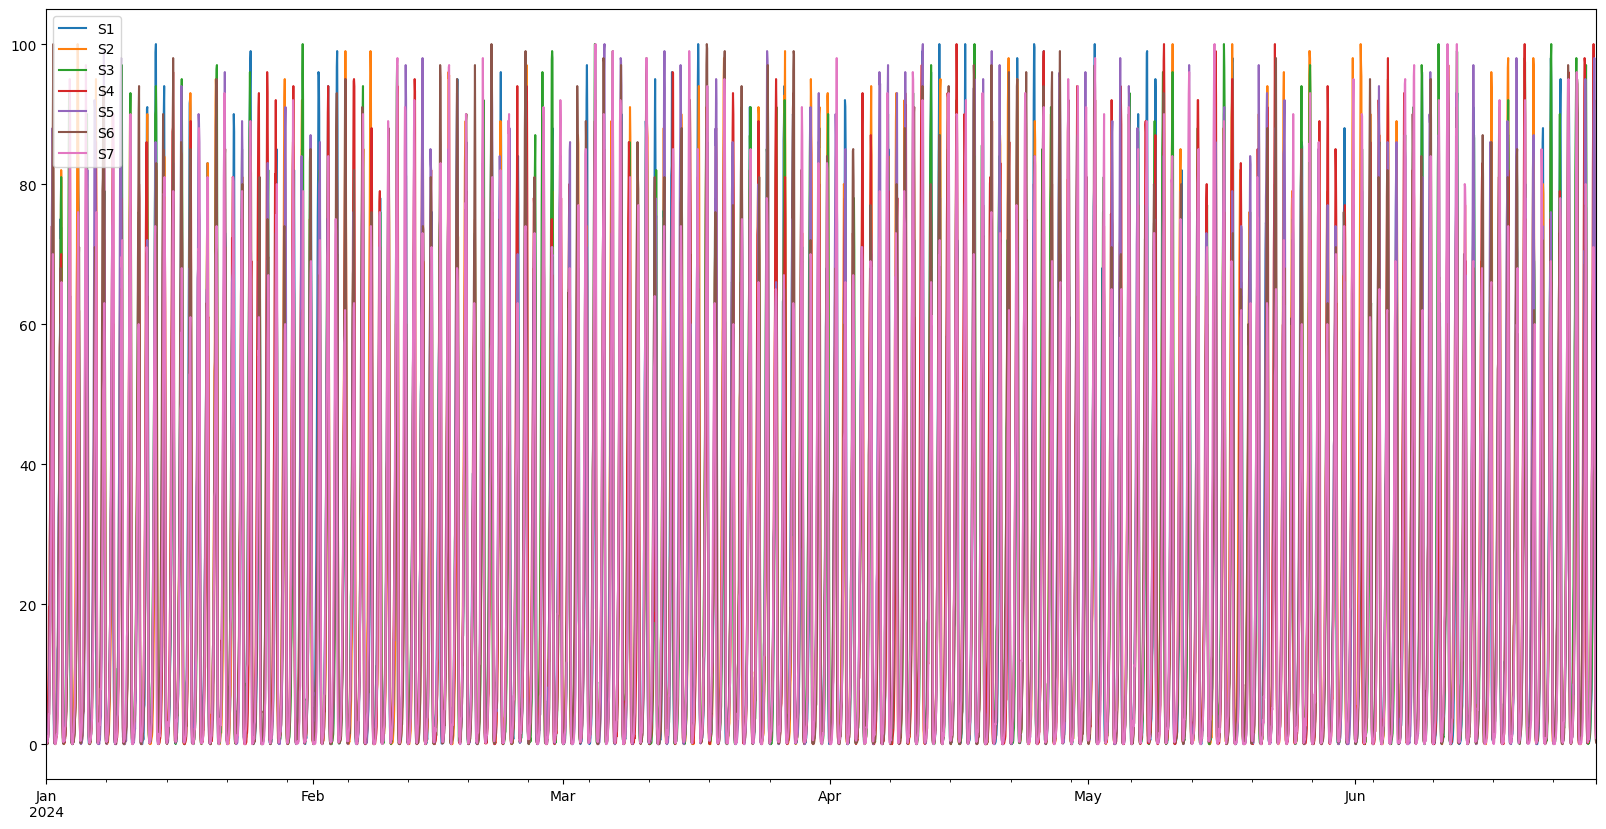

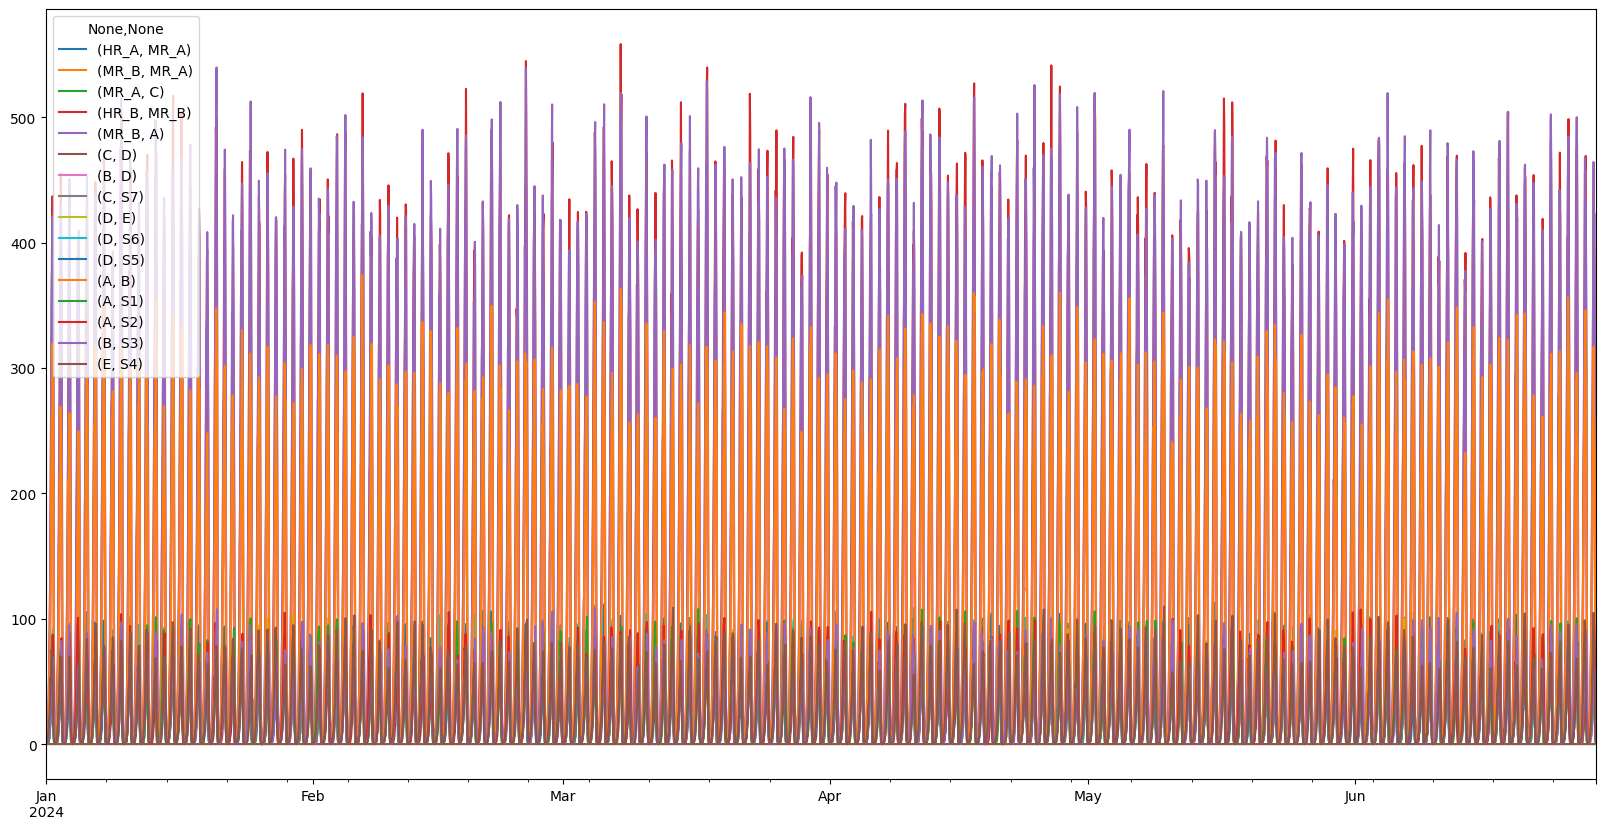

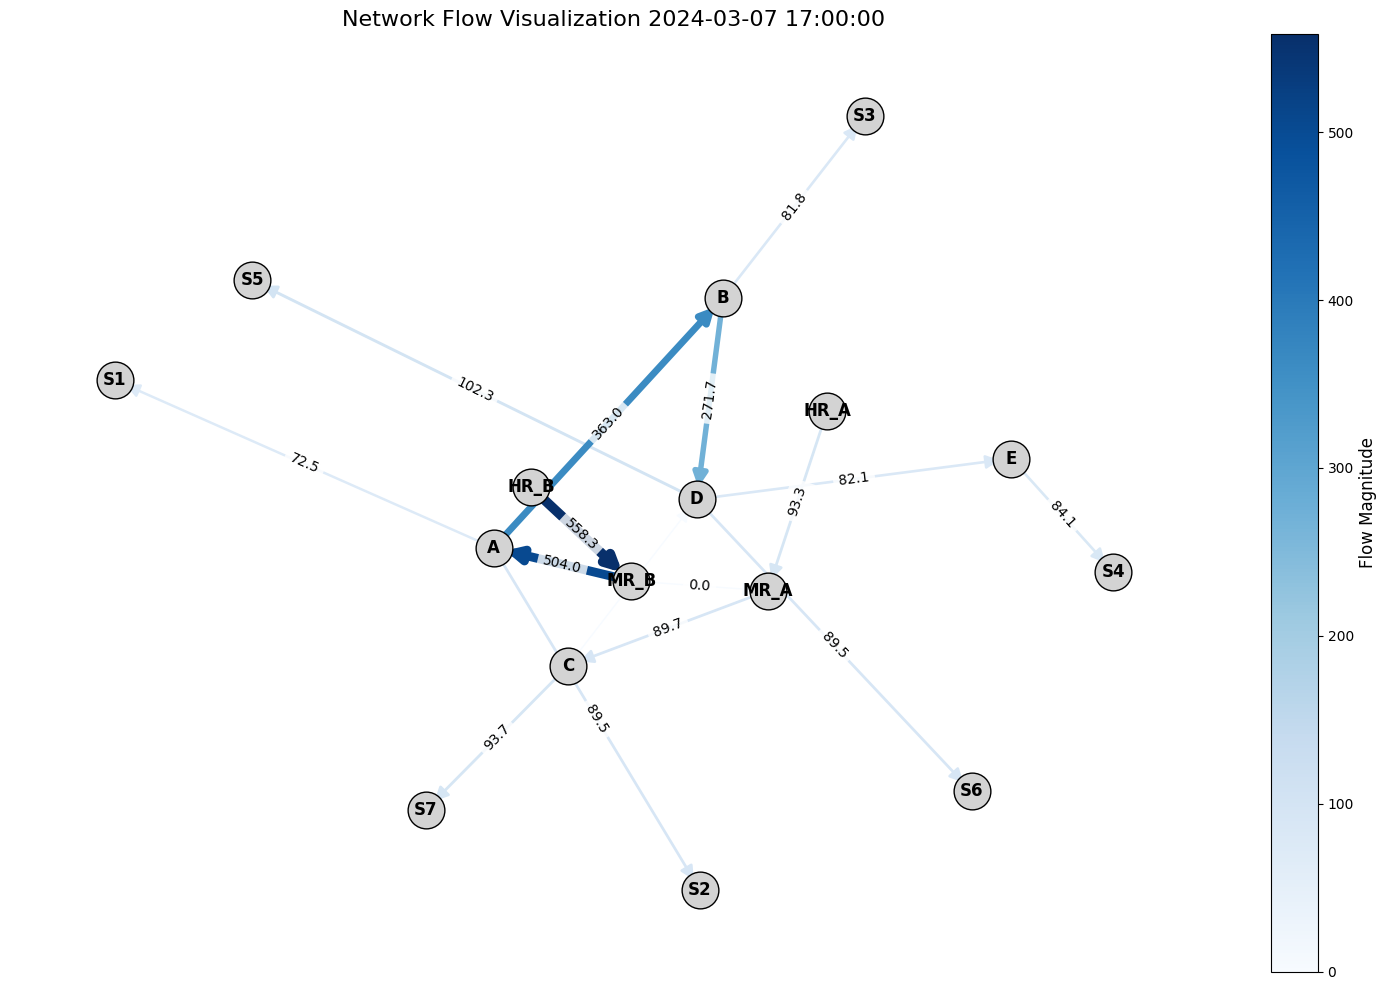

In [3]:
def create_skewed_series(n_points, max_val, skewness, sigma=1.0):
    """
    Generates a pandas Series of random numbers following a Skew Normal distribution,
    shifted so the maximum value equals 'max_val'.

    Args:
        n_points (int): The number of data points to generate.
        max_val (float): The maximum value (ceiling) of the dataset.
        skewness (float): The skew factor. 
                          0 = Normal distribution (symmetric).
                          Positive = Tail on the right (mass on left).
                          Negative = Tail on the left (mass on right).
        sigma (float): The scale (standard deviation) or 'width' of the curve.

    Returns:
        pd.Series: A Series containing the generated data.
    """
    # 1. Generate the raw Skew Normal distribution
    # 'a' is the skewness parameter
    # 'loc' is the mean, 'scale' is the standard deviation (sigma)
    raw_data = skewnorm.rvs(a=skewness, loc=0, scale=sigma, size=n_points)

    # 2. Shift the data to respect the 'max_val' constraint
    # We find the current generated max, and shift the whole dataset
    # so that the new max hits your target exactly.
    current_max = np.max(raw_data)
    shift_amount = max_val - current_max
    final_data = raw_data + shift_amount

    return pd.Series(final_data)

def create_day_demand(day:datetime, node:str, amp_range:int = (60, 100), skewness_range:int = (-6,-3), sigma_range:int = (7, 10), nn:int = 1440, points:int = 24):

    _max_val = random.randint(amp_range[0], amp_range[1])
    _skewness = random.randint(skewness_range[0], skewness_range[1])
    _sigma = random.randint(sigma_range[0], sigma_range[1])

    #print(f"Node: {node}, Max Val: {_max_val}, Skewness: {_skewness}, Sigma: {_sigma}")
    _curve = create_skewed_series(5000, _max_val, skewness=_skewness, sigma=_sigma)
    _curve = _curve.value_counts(bins=points).sort_index().reset_index(drop=True)
    _curve.name = node
    _curve.index = pd.date_range(start=day, periods=points, freq='h')
    _curve = _curve * _max_val/_curve.max()

    return _curve

def calculate_edge_flows(G, demands, capacity_attr='capacity'):
    """
    Calculates the flow through all edges in a Digraph to satisfy specific node demands.
    
    Args:
        G (nx.DiGraph): The networkx graph. Edges must have a capacity attribute.
        demands (dict): Dictionary {node_name: required_output_flow}.
        capacity_attr (str): The name of the edge attribute representing capacity.
        
    Returns:
        dict: A dictionary of dictionaries representing flow {u: {v: flow_amount}}.
    """
    # 1. Create a working copy of the graph to avoid modifying the original
    R = G.copy()
    
    # 2. Define Super Node names (ensure they don't clash with existing nodes)
    super_source = 'SUPER_SOURCE_VIRTUAL'
    super_sink = 'SUPER_SINK_VIRTUAL'
    
    # 3. Add the Super Sink
    # Connect demand nodes to Super Sink with capacity = demand
    total_demand = 0
    for node, demand in demands.items():
        if node not in R:
            raise ValueError(f"Demand node '{node}' is not in the graph.")
        R.add_edge(node, super_sink, **{capacity_attr: demand})
        total_demand += demand

    # 4. Add the Super Source
    # Identify potential sources: Nodes with 0 in-degree that aren't the super sink
    # If specific sources are known, you can pass them as a list instead of this auto-detection
    sources = [n for n in G.nodes() if G.in_degree(n) == 0]
    
    if not sources:
        # If the graph is a cycle (no 0 in-degree nodes), we might need to assume 
        # all non-demand nodes are potential sources, or raise an error.
        # Here, we default to connecting to all nodes that aren't sinks.
        sources = [n for n in G.nodes() if n not in demands]

    for source in sources:
        # Connect Super Source to sources with Infinite capacity
        R.add_edge(super_source, source, **{capacity_attr: float('inf')})

    # 5. Compute Maximum Flow
    try:
        flow_value, flow_dict = nx.maximum_flow(R, super_source, super_sink, capacity=capacity_attr)
    except nx.NetworkXError as e:
        print(f"Error computing flow: {e}")
        return {}

    # 6. Check if demands were met
    if flow_value < total_demand:
        print(f"WARNING: The network capacity ({flow_value}) is insufficient to meet total demand ({total_demand}).")
        print("Returning partial flow assignments.")

    # 7. Clean up the output
    # The flow_dict includes the virtual nodes; we need to strip them out.
    final_flow = {}
    for u, neighbors in flow_dict.items():
        # Skip if u is a virtual node
        if u in (super_source, super_sink):
            continue
            
        final_flow[u] = {}
        for v, flow in neighbors.items():
            # Skip if v is a virtual node
            if v in (super_source, super_sink):
                continue
            final_flow[u][v] = flow

    final_flow_df = pd.DataFrame(final_flow).stack().to_frame().rename(columns={0: 'Flow'}).swaplevel()

    return final_flow_df

def visualize_flow_series(G, flow_series, title="Network Flow Visualization"):
    """
    Visualizes a networkx Graph with flow values from a pandas Series.
    
    Parameters:
    - G: networkx.Graph or DiGraph
    - flow_series: pd.Series where index is edges (u,v) and values are floats.
    """
    
    # 1. Setup Figure
    plt.figure(figsize=(14, 10), facecolor='white')
    ax = plt.gca()
    ax.set_facecolor('white')

    # 2. Generate "Spread" Layout
    # We scale 'k' (repulsive force) based on node count to keep it sparse
    k_val = 2.0 / np.sqrt(len(G.nodes())) if len(G.nodes()) > 0 else 1
    pos = nx.spring_layout(G, k=k_val, iterations=50, seed=42)

    # 3. Process Edge Styles
    edge_colors = []
    edge_widths = []
    edge_labels = {}
    
    # Handle empty series or all zeros
    if flow_series.empty:
        max_val = 1.0
    else:
        max_val = flow_series.max()
        if max_val == 0: max_val = 1.0

    for u, v in G.edges():
        # Retrieve flow safely, checking both (u,v) and (v,u)
        val = 0.0
        if (u, v) in flow_series.index:
            val = flow_series.loc[(u, v)]
        elif (v, u) in flow_series.index:
            val = flow_series.loc[(v, u)]
        
        # Color: Map value directly
        edge_colors.append(val)
        
        # Width: Base width (1.0) + scaled extra width (up to 6.0)
        width_scale = 1.0 + (val / max_val) * 6.0
        edge_widths.append(width_scale)
        
        # Label: formatted string
        edge_labels[(u, v)] = f"{val:.1f}"

    # 4. Draw Components
    
    # Draw Nodes
    nx.draw_networkx_nodes(G, pos, node_size=700, node_color='lightgrey', edgecolors='black')
    
    # Draw Node Labels
    nx.draw_networkx_labels(G, pos, font_color='black', font_weight='bold')

    # Draw Edges
    # We use a colormap (Blues) to visualize intensity
    cmap = plt.cm.Blues
    nx.draw_networkx_edges(G, pos, 
                           width=edge_widths, 
                           edge_color=edge_colors, 
                           edge_cmap=cmap, 
                           edge_vmin=0, 
                           edge_vmax=max_val,
                           arrows=True, arrowstyle='-|>', arrowsize=20)
    
    # Draw Flow Values (with white background for readability)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, 
                                 font_color='black', font_size=10,
                                 bbox=dict(facecolor='white', edgecolor='none', alpha=0.8))

    # 5. Add Colorbar (Robust Method)
    # Create a 'ScalarMappable' explicitly to avoid AttributeError
    norm = mcolors.Normalize(vmin=0, vmax=max_val)
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([]) 
    
    cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Flow Magnitude', color='black', size=12)
    cbar.ax.yaxis.set_tick_params(color='black', labelcolor='black')

    # 6. Final Polish
    plt.title(title, fontsize=16, color='black')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

def analyze_specific_flow(flow_dict):
    # 2. Reconstruct the Graph from the keys
    G = nx.DiGraph()
    G.add_edges_from(flow_dict.keys())
    
    # 3. Auto-detect Sources and Sinks
    # Sources = Nodes with In-Degree 0
    sources = [n for n in G.nodes if G.in_degree(n) == 0]
    # Sinks = Nodes with Out-Degree 0
    sinks = [n for n in G.nodes if G.out_degree(n) == 0]
    
    print(f"Detected Sources (Inputs): {sources}")
    print(f"Detected Sinks (Outputs): {sinks}")
    
    results = []
    
    # 4. Calculate Balance for Internal Nodes
    for node in G.nodes:
        if node in sources or node in sinks:
            continue
            
        flow_in = 0.0
        flow_out = 0.0
        
        # Sum Inputs
        for u in G.predecessors(node):
            flow_in += flow_dict.get((u, node), 0.0)
            
        # Sum Outputs
        for v in G.successors(node):
            flow_out += flow_dict.get((node, v), 0.0)
            
        balance = flow_in - flow_out
        
        # Determine status
        if abs(balance) < 1e-4:
            status = "✅ Balanced"
        elif balance > 0:
            status = "⚠️ Accumulation (In > Out)"
        else:
            status = "🔻 Leak/Gain (Out > In)" # Out is higher, so flow appeared
            
        results.append({
            "Node": node,
            "Flow In": round(flow_in, 3),
            "Flow Out": round(flow_out, 3),
            "Diff": round(balance, 3),
            "Status": status
        })
        
    #return pd.DataFrame(results).set_index("Node")
    return pd.DataFrame(results).set_index("Node").Diff.mean()


G = nx.DiGraph()
G.add_edge('HR_A', 'MR_A', capacity=10000)
G.add_edge('HR_B', 'MR_B', capacity=10000)
G.add_edge('MR_B', 'MR_A', capacity=10000)
G.add_edge('MR_A', 'C', capacity=10000)

G.add_edge('C', 'D', capacity=10000)
G.add_edge('MR_B', 'A', capacity=10000)
G.add_edge('A', 'B', capacity=10000)
G.add_edge('B', 'D', capacity=10000)
G.add_edge('D', 'E', capacity=10000)

G.add_edge('C', 'S7', capacity=10000)
G.add_edge('D', 'S6', capacity=10000)
G.add_edge('D', 'S5', capacity=10000)
G.add_edge('B', 'S3', capacity=10000)
G.add_edge('A', 'S1', capacity=10000)
G.add_edge('A', 'S2', capacity=10000)
G.add_edge('E', 'S4', capacity=10000)


DEMANDS_NODES = ['S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7']
DAY_START = datetime(2024, 1, 1)
RANGE_MONTHS = 6
RANGE_DATE = pd.date_range(start=DAY_START, periods=RANGE_MONTHS*30, freq='D')


DEMANDS = []
for _day in RANGE_DATE:
    _demands_day = {}
    for _node in DEMANDS_NODES:
        _demands_day[_node] = create_day_demand(_day, _node)
    DEMANDS.append(pd.DataFrame(_demands_day))

DEMANDS = pd.concat(DEMANDS)
display(DEMANDS.plot(figsize=(20,10)))


RAW_DATA = pd.DataFrame()
for k,v in DEMANDS.iterrows():
    _flow = calculate_edge_flows(G, v.to_dict() )
    _flow.columns = [k]   
    RAW_DATA = pd.concat([RAW_DATA, _flow], axis=1)

clear_output()

# SIULATING NOISE
NOISE =  np.random.normal(loc=0, scale=0.05, size=RAW_DATA.shape)
RAW_DATA = RAW_DATA*(1+NOISE)

display(RAW_DATA.T.plot(figsize=(20,10)))

timestamp = RAW_DATA.sum().idxmax() #RAW_DATA.T.sample().index[0]
print(timestamp)

visualize_flow_series(
    G, 
    RAW_DATA.loc[:,timestamp], 
    title="Network Flow Visualization {}".format(timestamp)
)

Detected Sources (Inputs): ['HR_A', 'HR_B']
Detected Sinks (Outputs): ['S7', 'S6', 'S5', 'S1', 'S2', 'S3', 'S4']
Detected Sources (Inputs): ['HR_A', 'HR_B']
Detected Sinks (Outputs): ['S7', 'S6', 'S5', 'S1', 'S2', 'S3', 'S4']
Detected Sources (Inputs): ['HR_A', 'HR_B']
Detected Sinks (Outputs): ['S7', 'S6', 'S5', 'S1', 'S2', 'S3', 'S4']
Detected Sources (Inputs): ['HR_A', 'HR_B']
Detected Sinks (Outputs): ['S7', 'S6', 'S5', 'S1', 'S2', 'S3', 'S4']
Detected Sources (Inputs): ['HR_A', 'HR_B']
Detected Sinks (Outputs): ['S7', 'S6', 'S5', 'S1', 'S2', 'S3', 'S4']
Detected Sources (Inputs): ['HR_A', 'HR_B']
Detected Sinks (Outputs): ['S7', 'S6', 'S5', 'S1', 'S2', 'S3', 'S4']
Detected Sources (Inputs): ['HR_A', 'HR_B']
Detected Sinks (Outputs): ['S7', 'S6', 'S5', 'S1', 'S2', 'S3', 'S4']
Detected Sources (Inputs): ['HR_A', 'HR_B']
Detected Sinks (Outputs): ['S7', 'S6', 'S5', 'S1', 'S2', 'S3', 'S4']
Detected Sources (Inputs): ['HR_A', 'HR_B']
Detected Sinks (Outputs): ['S7', 'S6', 'S5', 'S1', '

<Axes: >

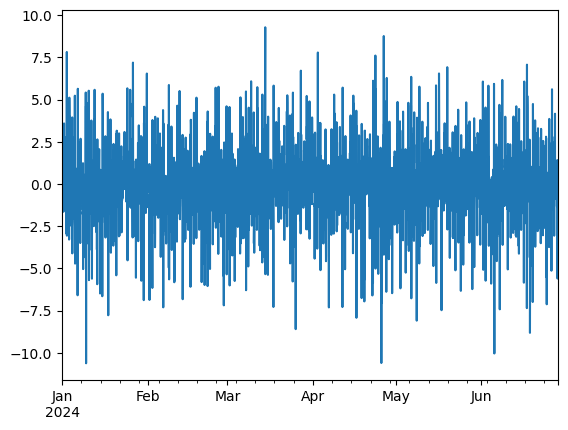

In [4]:
balanced_analysis =RAW_DATA.apply( lambda x: analyze_specific_flow(x.to_dict()) )
balanced_analysis.plot()

## PREPARATION OF DATA

In [10]:
SAMPLING = '3h'
TSS = RAW_DATA.T.copy()

ORIG_COLUMNS = {f"chn_{i}":TSS.columns[i] for i in range(len(TSS.columns))}
ORIG_COLUMNS_INV = {TSS.columns[i]:f"chn_{i}" for i in range(len(TSS.columns))}
ORDER_COLS = [f"chn_{i}" for i in range(len(ORIG_COLUMNS))]
display(ORIG_COLUMNS)
display(ORDER_COLS)
TSS.columns = [f"chn_{i}" for i in range(len(ORIG_COLUMNS))]

TSS = TSS.resample(SAMPLING).mean()
TSS

{'chn_0': ('HR_A', 'MR_A'),
 'chn_1': ('MR_B', 'MR_A'),
 'chn_2': ('MR_A', 'C'),
 'chn_3': ('HR_B', 'MR_B'),
 'chn_4': ('MR_B', 'A'),
 'chn_5': ('C', 'D'),
 'chn_6': ('B', 'D'),
 'chn_7': ('C', 'S7'),
 'chn_8': ('D', 'E'),
 'chn_9': ('D', 'S6'),
 'chn_10': ('D', 'S5'),
 'chn_11': ('A', 'B'),
 'chn_12': ('A', 'S1'),
 'chn_13': ('A', 'S2'),
 'chn_14': ('B', 'S3'),
 'chn_15': ('E', 'S4')}

['chn_0',
 'chn_1',
 'chn_2',
 'chn_3',
 'chn_4',
 'chn_5',
 'chn_6',
 'chn_7',
 'chn_8',
 'chn_9',
 'chn_10',
 'chn_11',
 'chn_12',
 'chn_13',
 'chn_14',
 'chn_15']

,chn_0,chn_1,chn_2,chn_3,chn_4,chn_5,chn_6,chn_7,chn_8,chn_9,chn_10,chn_11,chn_12,chn_13,chn_14,chn_15
2024-01-01 00:00:00,0.582647,0.0,0.583617,1.090026,1.155056,0.563312,0.598143,0.094511,0.828963,0.085372,0.183377,0.842646,0.087214,0.220539,0.212752,0.864559
2024-01-01 03:00:00,2.639476,0.0,2.546901,6.521652,6.434808,1.886750,3.516354,0.582968,3.829073,0.370341,1.218017,4.661591,0.493460,1.309509,1.094024,3.849162
2024-01-01 06:00:00,2.507589,0.0,2.557218,33.170300,31.531304,0.000000,20.103263,2.364363,12.797027,1.789013,4.496509,24.258985,2.985005,5.221652,4.937489,13.286228
2024-01-01 09:00:00,8.337506,0.0,8.692813,95.999425,96.178682,0.000000,56.003701,9.035851,27.394862,8.589537,17.198118,64.364704,11.372629,16.034692,12.204239,28.238290
2024-01-01 12:00:00,25.842980,0.0,25.739917,219.077620,219.875533,0.000000,125.355059,24.860978,55.954528,25.372820,40.389130,143.181281,33.160138,34.861762,28.725157,54.672064
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-06-28 09:00:00,27.664837,0.0,27.503903,109.028985,113.732754,0.000000,79.510757,27.397000,24.861243,26.709817,22.739560,84.500053,7.569888,22.469476,8.560235,24.803054
2024-06-28 12:00:00,49.536422,0.0,52.279108,269.352691,255.352544,0.000000,176.567093,53.675940,62.187538,55.346218,49.963853,197.882798,21.711597,50.058729,23.493965,66.702979
2024-06-28 15:00:00,69.565663,0.0,71.235851,419.751303,418.325388,0.000000,237.816164,66.383060,93.582074,65.555452,84.680730,284.901685,39.674088,86.507238,45.576743,97.002267
2024-06-28 18:00:00,35.509170,0.0,34.242521,334.002732,345.635556,0.000000,165.342457,35.633470,48.920166,26.969414,87.682949,209.289945,58.513136,70.748648,56.593409,49.762267


# GMAN

## ADJENCY MATRIX

In [30]:
def build_link_graph(router_edges):
    
    G_physical = nx.DiGraph()
    
    for src_dst, link_id in router_edges.items():
        G_physical.add_edge(src_dst[0], src_dst[1], id=link_id)

    G_line = nx.line_graph(G_physical)

    _line_graph = [(router_edges[ed[0]],router_edges[ed[1]]) for ed in G_line.edges()]

    G_link = nx.DiGraph()
    for src, dst in _line_graph:
        G_link.add_edge(src, dst)

    return  nx.to_pandas_adjacency(G_link, dtype=int)
    
  
#physical_topology = {(x[0],x[1]):x[2] for x in DATA_RAW.index.values}

ADJ_M = build_link_graph(ORIG_COLUMNS_INV)
ADJ_M = ADJ_M.loc[ORDER_COLS, ORDER_COLS]
ADJ_M_DF = ADJ_M.copy()
ADJ_M = ADJ_M.to_numpy()

display(pd.DataFrame( ADJ_M, columns=list(map(ORIG_COLUMNS.get, ORDER_COLS)), index=list(map(ORIG_COLUMNS.get, ORDER_COLS))))
ADJ_M.shape



,"(HR_A, MR_A)","(MR_B, MR_A)","(MR_A, C)","(HR_B, MR_B)","(MR_B, A)","(C, D)","(B, D)","(C, S7)","(D, E)","(D, S6)","(D, S5)","(A, B)","(A, S1)","(A, S2)","(B, S3)","(E, S4)"
"(HR_A, MR_A)",0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
"(MR_B, MR_A)",0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
"(MR_A, C)",0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0
"(HR_B, MR_B)",0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0
"(MR_B, A)",0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0
"(C, D)",0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0
"(B, D)",0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0
"(C, S7)",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"(D, E)",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
"(D, S6)",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


(16, 16)

# DATA_PREPARATION

In [32]:
DATA_RAW_MODEL = TSS.copy()
DATA_RAW_MODEL = DATA_RAW_MODEL.round(2)
DATA_RAW_MODEL = DATA_RAW_MODEL[ORDER_COLS] 
DATA_RAW_MODEL

,chn_0,chn_1,chn_2,chn_3,chn_4,chn_5,chn_6,chn_7,chn_8,chn_9,chn_10,chn_11,chn_12,chn_13,chn_14,chn_15
2024-01-01 00:00:00,0.58,0.0,0.58,1.09,1.16,0.56,0.60,0.09,0.83,0.09,0.18,0.84,0.09,0.22,0.21,0.86
2024-01-01 03:00:00,2.64,0.0,2.55,6.52,6.43,1.89,3.52,0.58,3.83,0.37,1.22,4.66,0.49,1.31,1.09,3.85
2024-01-01 06:00:00,2.51,0.0,2.56,33.17,31.53,0.00,20.10,2.36,12.80,1.79,4.50,24.26,2.99,5.22,4.94,13.29
2024-01-01 09:00:00,8.34,0.0,8.69,96.00,96.18,0.00,56.00,9.04,27.39,8.59,17.20,64.36,11.37,16.03,12.20,28.24
2024-01-01 12:00:00,25.84,0.0,25.74,219.08,219.88,0.00,125.36,24.86,55.95,25.37,40.39,143.18,33.16,34.86,28.73,54.67
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-06-28 09:00:00,27.66,0.0,27.50,109.03,113.73,0.00,79.51,27.40,24.86,26.71,22.74,84.50,7.57,22.47,8.56,24.80
2024-06-28 12:00:00,49.54,0.0,52.28,269.35,255.35,0.00,176.57,53.68,62.19,55.35,49.96,197.88,21.71,50.06,23.49,66.70
2024-06-28 15:00:00,69.57,0.0,71.24,419.75,418.33,0.00,237.82,66.38,93.58,65.56,84.68,284.90,39.67,86.51,45.58,97.00
2024-06-28 18:00:00,35.51,0.0,34.24,334.00,345.64,0.00,165.34,35.63,48.92,26.97,87.68,209.29,58.51,70.75,56.59,49.76


### PARAMETERS

In [47]:
# TRAINING PARAMS
BATCH_SIZE = 32
EPOCHS = 60
LR = 0.001

# DATASET PARAMS
FREQ_H = int(re.search(r'[a-z]*(\d+)[a-z]*', SAMPLING)[1])
FREQ_MINUTES = FREQ_H*60
NUM_NODES = ADJ_M.shape[0]
HIST_STEPS = int(2*30*(24/FREQ_H))          # 2 months
PRED_STEPS = int(1*30*(24/FREQ_H))          # 1 month
INPUT_DIM = 1
OUTPUT_DIM = 1
D_MODEL = 32

STEPS_PER_DAY = int(24/FREQ_H)
DAYS_PER_WEEK = 7
MONTHS_PER_YEAR = 12


TIME_FEATURES = STEPS_PER_DAY + DAYS_PER_WEEK + MONTHS_PER_YEAR 

print(f"Frequency: {FREQ_H} hours")
print(f"Frequency: {FREQ_MINUTES} minutes")
print(f"Number of nodes: {NUM_NODES}")
print(f"Number of historical steps: {HIST_STEPS}")
print(f"Number of prediction steps: {PRED_STEPS}")
print(f"Number of time features: {TIME_FEATURES}")
print(f"Input dimension: {INPUT_DIM}")
print(f"Output dimension: {OUTPUT_DIM}")
print(f"Model dimension: {D_MODEL}")
print(f"Steps per day: {STEPS_PER_DAY}")
print(f"Days per week: {DAYS_PER_WEEK}")
print(f"Months per year: {MONTHS_PER_YEAR}")

Frequency: 3 hours
Frequency: 180 minutes
Number of nodes: 16
Number of historical steps: 480
Number of prediction steps: 240
Number of time features: 27
Input dimension: 1
Output dimension: 1
Model dimension: 32
Steps per day: 8
Days per week: 7
Months per year: 12


### CREATE DATASET

In [58]:
from node2vec import Node2Vec
import networkx as nx
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader,TensorDataset, Subset



In [41]:
#!pip install node2vec

In [48]:
class NetworkTrafficDataset(Dataset):
    def __init__(self, dataframe, num_his, num_pred, time_slot_min=5):
        """
        dataframe: Rows=Time, Cols=Links
        num_his: History steps (P)
        num_pred: Prediction steps (Q)
        time_slot_min: Granularity of data in minutes (used for Time Embedding)
        """
        self.data = dataframe.values.astype(np.float32)
        self.num_his = num_his
        self.num_pred = num_pred
        
        # --- Create Temporal Embeddings (TE) ---
        # TE shape: [Total_Steps, 2] -> (DayOfWeek, TimeOfDay)
        time_index = pd.to_datetime(dataframe.index)
        
        # Calculate steps per day based on data granularity
        self.steps_per_day = (24 * 60) // time_slot_min
        
        dow = time_index.dayofweek.values.reshape(-1, 1)
        # Calculate time of day index (0 to steps_per_day-1)
        tod = ((time_index.hour * 60 + time_index.minute) // time_slot_min).values.reshape(-1, 1)
        moy = time_index.month.values.reshape(-1, 1)
        
        self.TE = np.concatenate((dow, tod, moy), axis=-1).astype(np.int32)
        
        # Normalize Data
        self.mean = np.mean(self.data)
        self.std = np.std(self.data)
        self.data = (self.data - self.mean) / self.std
        
    def reverse_transform(self, x_scaled):
        """
        Reverses the Z-score normalization.
        Accepts: Numpy Arrays or PyTorch Tensors.
        """
        # If x_scaled is a Tensor, move it to CPU/Numpy if necessary, 
        # OR convert mean/std to Tensor. 
        # The simplest way that works for both is usually:
        
        if torch.is_tensor(x_scaled):
            # Option A: Convert output to numpy (Good for plotting)
            x_scaled = x_scaled.detach().cpu().numpy()
            return (x_scaled * self.std) + self.mean
        else:
            # Option B: Input is already numpy
            return (x_scaled * self.std) + self.mean

    def __len__(self):
        return len(self.data) - self.num_his - self.num_pred + 1

    def __getitem__(self, idx):
        # Sliding window
        # X: History [P, N]
        X = self.data[idx : idx + self.num_his]
        
        # Y: Target [Q, N]
        Y = self.data[idx + self.num_his : idx + self.num_his + self.num_pred]
        
        # TE: Temporal Embedding [P + Q, 2]
        TE = self.TE[idx : idx + self.num_his + self.num_pred]
        
        return torch.tensor(X), torch.tensor(TE), torch.tensor(Y)


if DEBUG:
    DATA_RAW_DS = NetworkTrafficDataset(DATA_RAW_MODEL, num_his=HIST_STEPS, num_pred=PRED_STEPS, time_slot_min=FREQ_MINUTES)
    print(f"Dataset size: {len(DATA_RAW_DS)}")
    print(f"Data shape: {DATA_RAW_DS[0][0].shape}")
    print(f"TE shape: {DATA_RAW_DS[0][1].shape}")
    print(f"Target shape: {DATA_RAW_DS[0][2].shape}")
    DATA_RAW_DL = DataLoader(DATA_RAW_DS, batch_size=BATCH_SIZE, shuffle=True)


Dataset size: 721
Data shape: torch.Size([480, 16])
TE shape: torch.Size([720, 3])
Target shape: torch.Size([240, 16])


In [49]:
def generate_node2vec_embeddings(adj_m, embedding_dim=64):
    """
    Generates node embeddings using Node2Vec.
    adj_matrix: (N, N) numpy array (adjacency matrix)
    """
    adj_matrix = adj_m


    # Create Graph
    rows, cols = np.where(adj_matrix > 0)
    G = nx.Graph() 
    for r, c in zip(rows, cols):
        G.add_edge(r, c, weight=adj_matrix[r, c])
        
    # Run Node2Vec
    # P=1, Q=1 is standard equivalent to DeepWalk, adjust for BFS/DFS bias
    node2vec = Node2Vec(G, dimensions=embedding_dim, walk_length=12, num_walks=100, workers=1, quiet=False)
    model = node2vec.fit(window=4, min_count=1, batch_words=4)
    
    # Extract vectors in order
    num_nodes = adj_matrix.shape[0]
    embeddings = np.zeros((num_nodes, embedding_dim))
    for i in range(num_nodes):
        if str(i) in model.wv:
            embeddings[i] = model.wv[str(i)]
        else:
            print(f"Node {i} not found in Node2Vec model")
            embeddings[i] = np.random.normal(0, 0.1, embedding_dim)
            
    return torch.tensor(embeddings, dtype=torch.float32)

if DEBUG:
    node_vectors = generate_node2vec_embeddings(ADJ_M, embedding_dim=D_MODEL)
    print(f"Node Vectors Shape: {node_vectors.shape}")

Generating walks (CPU: 1): 100%|██████████| 100/100 [00:00<00:00, 1964.08it/s]


Node Vectors Shape: torch.Size([16, 32])


### MODEL

In [50]:
class FC(nn.Module):
    def __init__(self, input_dims, units, activations, bn_decay, use_bias=True):
        super(FC, self).__init__()
        if isinstance(units, int):
            units, input_dims, activations = [units], [input_dims], [activations]
            
        self.layers = nn.ModuleList()
        print(f"input_dims: {input_dims}, units: {units}, activations: {activations}")
        for inp, out, act in zip(input_dims, units, activations):
            self.layers.append(nn.Sequential(
                nn.Conv2d(inp, out, kernel_size=1, bias=use_bias),
                nn.BatchNorm2d(out, momentum=bn_decay),
                act if act is not None else nn.Identity()
            ))

    def forward(self, x):
        # Input shape: [Batch, Dim, Steps, Nodes]
        for layer in self.layers:
            x = layer(x)
        return x

class STEmbedding(nn.Module):
    def __init__(self, D, bn_decay, steps_per_day):
        super(STEmbedding, self).__init__()
        self.steps_per_day = steps_per_day
        
        # Spatial Embedding FC: Input D -> Hidden D -> Output D
        self.FC_se = FC([D, D], [D, D], [nn.ReLU(), None], bn_decay)
        
        # Temporal Embedding FC
        # Input features: 7 (DoW) + steps_per_day (ToD) + 12 (Month)
        input_te_dim = 7 + steps_per_day + 12
        
        # We pass a list of input dims matching the list of units [D, D]
        self.FC_te = FC([input_te_dim, D], [D, D], [nn.ReLU(), None], bn_decay)

    def forward(self, SE, TE):
        # SE: [N, D] -> [1, D, 1, N]
        SE = SE.unsqueeze(0).unsqueeze(2).permute(0, 3, 2, 1)
        SE = self.FC_se(SE)
        
        # TE: [Batch, Steps, 3] -> (Day, Time, Month)
        dayofweek = F.one_hot(TE[..., 0].long() % 7, 7)
        timeofday = F.one_hot(TE[..., 1].long() % self.steps_per_day, self.steps_per_day)
        monthofyear = F.one_hot(TE[..., 2].long() % 12, 12) # New Month One-Hot
        
        # Concatenate all temporal features
        # Shape: [Batch, Steps, 7 + steps_per_day + 12]
        TE = torch.cat((dayofweek, timeofday, monthofyear), dim=-1).float()
        
        # Permute to [Batch, Channels, Steps, 1] for Conv2d usage in FC
        TE = TE.permute(0, 2, 1).unsqueeze(-1)
        
        # Apply FC to project to D dimensions
        TE = self.FC_te(TE)
        
        # Add Spatial and Temporal Embeddings
        # Broadcasting: [1, D, 1, N] + [Batch, D, Steps, 1] -> [Batch, D, Steps, N]
        return SE + TE

class STAttBlock(nn.Module):
    def __init__(self, K, d, bn_decay, mask=False):
        super(STAttBlock, self).__init__()
        D = K * d
        self.K = K
        self.d = d
        self.mask = mask
        
        # Attention Projections
        self.fc_q = FC(2*D, D, nn.ReLU(), bn_decay)
        self.fc_k = FC(2*D, D, nn.ReLU(), bn_decay)
        self.fc_v = FC(2*D, D, nn.ReLU(), bn_decay)
        self.fc_out = FC(D, D, nn.ReLU(), bn_decay)
        
        # Gated Fusion
        self.fc_xs = FC(D, D, None, bn_decay, use_bias=False)
        self.fc_xt = FC(D, D, None, bn_decay, use_bias=True)
        self.fc_h = FC(D, D, nn.ReLU(), bn_decay)

    def spatial_att(self, X, STE):
        # X, STE: [Batch, D, Steps, Nodes]
        inp = torch.cat((X, STE), dim=1)
        q = self.fc_q(inp).permute(0, 2, 3, 1) # [B, T, N, D]
        k = self.fc_k(inp).permute(0, 2, 3, 1)
        v = self.fc_v(inp).permute(0, 2, 3, 1)
        
        # Split Heads: [B, T, N, K, d]
        q = q.view(q.shape[0], q.shape[1], q.shape[2], self.K, self.d).permute(3, 0, 1, 2, 4) # [K, B, T, N, d]
        k = k.view(k.shape[0], k.shape[1], k.shape[2], self.K, self.d).permute(3, 0, 1, 2, 4)
        v = v.view(v.shape[0], v.shape[1], v.shape[2], self.K, self.d).permute(3, 0, 1, 2, 4)
        
        # Attention: [K, B, T, N, N]
        att = torch.matmul(q, k.transpose(-1, -2)) / (self.d**0.5)
        att = F.softmax(att, dim=-1)
        
        out = torch.matmul(att, v) # [K, B, T, N, d]
        out = out.permute(1, 3, 2, 0, 4).reshape(X.shape[0], -1, X.shape[2], X.shape[3]) # [B, D, T, N] (permuted back to NCHW-ish)
        out = out.permute(0, 1, 2, 3) # ensure matches standard
        return self.fc_out(out)

    def temporal_att(self, X, STE):
        inp = torch.cat((X, STE), dim=1)
        q = self.fc_q(inp).permute(0, 3, 2, 1) # [B, N, T, D]
        k = self.fc_k(inp).permute(0, 3, 2, 1)
        v = self.fc_v(inp).permute(0, 3, 2, 1)
        
        q = q.view(q.shape[0], q.shape[1], q.shape[2], self.K, self.d).permute(3, 0, 1, 2, 4) # [K, B, N, T, d]
        k = k.view(k.shape[0], k.shape[1], k.shape[2], self.K, self.d).permute(3, 0, 1, 2, 4)
        v = v.view(v.shape[0], v.shape[1], v.shape[2], self.K, self.d).permute(3, 0, 1, 2, 4)
        
        att = torch.matmul(q, k.transpose(-1, -2)) / (self.d**0.5)
        
        if self.mask:
            # Casual Mask
            steps = att.shape[-1]
            mask = torch.tril(torch.ones(steps, steps)).to(att.device)
            att = att.masked_fill(mask == 0, -1e9)
            
        att = F.softmax(att, dim=-1)
        out = torch.matmul(att, v)
        out = out.permute(1, 4, 3, 2, 0).reshape(X.shape[0], -1, X.shape[2], X.shape[3])
        return self.fc_out(out)

    def forward(self, X, STE):
        # X shape: [Batch, D, Steps, Nodes]
        HS = self.spatial_att(X, STE)
        HT = self.temporal_att(X, STE)
        
        # Gated Fusion
        z = torch.sigmoid(self.fc_xs(HS) + self.fc_xt(HT))
        H = self.fc_h(z * HS + (1-z) * HT)
        return X + H

class TransformAttention(nn.Module):
    def __init__(self, K, d, bn_decay):
        super(TransformAttention, self).__init__()
        D = K * d
        self.K = K
        self.d = d
        
        # Projections for Query, Key, Value
        self.fc_q = FC(D, D, nn.ReLU(), bn_decay)
        self.fc_k = FC(D, D, nn.ReLU(), bn_decay)
        self.fc_v = FC(D, D, nn.ReLU(), bn_decay)
        
        # Output Projection
        self.fc_out = FC(D, D, nn.ReLU(), bn_decay)

    def forward(self, X, STE_P, STE_Q):
        """
        X:      History Features [Batch, D, P, N]
        STE_P:  History Embeddings [Batch, D, P, N]
        STE_Q:  Prediction Embeddings [Batch, D, Q, N]
        """
        batch_size = X.shape[0]
        
        # 1. Generate Q, K, V
        # Query comes from Prediction Embeddings (STE_Q)
        query = self.fc_q(STE_Q)  # [Batch, D, Q, N]
        
        # Key comes from History Embeddings (STE_P)
        key = self.fc_k(STE_P)    # [Batch, D, P, N]
        
        # Value comes from History Features (X)
        value = self.fc_v(X)      # [Batch, D, P, N]
        
        # 2. Split Heads and Permute
        # Goal: [K*Batch, N, Steps, d]
        
        # Query: [Batch, K*d, Q, N] -> [K*Batch, N, Q, d]
        query = torch.cat(torch.split(query, self.d, dim=1), dim=0)
        query = query.permute(0, 3, 2, 1) 
        
        # Key: [Batch, K*d, P, N] -> [K*Batch, N, d, P] (Transposed for MatMul)
        key = torch.cat(torch.split(key, self.d, dim=1), dim=0)
        key = key.permute(0, 3, 1, 2) 
        
        # Value: [Batch, K*d, P, N] -> [K*Batch, N, P, d]
        value = torch.cat(torch.split(value, self.d, dim=1), dim=0)
        value = value.permute(0, 3, 2, 1)
        
        # 3. Attention Mechanism
        # (Query @ Key) -> [K*Batch, N, Q, P]
        # This relates every future step Q to every past step P
        attention = torch.matmul(query, key)
        attention /= (self.d ** 0.5)
        attention = F.softmax(attention, dim=-1)
        
        # 4. Weighted Sum
        # (Att @ Value) -> [K*Batch, N, Q, d]
        X_trans = torch.matmul(attention, value)
        
        # 5. Restore Shape
        # [K*Batch, N, Q, d] -> [Batch, D, Q, N]
        X_trans = X_trans.permute(0, 3, 2, 1) # [K*Batch, d, Q, N]
        X_trans = torch.cat(torch.split(X_trans, batch_size, dim=0), dim=1)
        
        # 6. Final Projection
        X_trans = self.fc_out(X_trans)

        return X_trans

class GMAN(nn.Module):
    def __init__(self, SE, args):
        super(GMAN, self).__init__()
        self.num_his = args['num_his']
        self.num_pred = args['num_pred']
        self.SE = nn.Parameter(SE)
        D = args['K'] * args['d']
        
        # Embeddings & Projections
        self.st_embedding = STEmbedding(D, args['bn_decay'], args['steps_per_day'])
        self.fc_in = FC(1, D, nn.ReLU(), args['bn_decay'])
        
        self.fc_out = FC(D, 1, None, args['bn_decay'])
        #self.fc_out = nn.Conv2d(D, 1, kernel_size=1, bias=True)
        
        # Encoder
        self.encoder = nn.ModuleList([
            STAttBlock(args['K'], args['d'], args['bn_decay']) 
            for _ in range(args['L'])
        ])
        
        # --- Transform Attention (Full Implementation) ---
        self.trans_att = TransformAttention(args['K'], args['d'], args['bn_decay'])
        
        # Decoder
        self.decoder = nn.ModuleList([
            STAttBlock(args['K'], args['d'], args['bn_decay']) 
            for _ in range(args['L'])
        ])

    def forward(self, X, TE):
        # X Input: [Batch, P, N]
        X = X.unsqueeze(1).permute(0, 1, 2, 3) # [Batch, 1, P, N]
        X = self.fc_in(X) # [Batch, D, P, N]
        
        # Generate ST Embeddings for full sequence (P + Q)
        STE = self.st_embedding(self.SE, TE) # [Batch, D, P+Q, N]
        STE_P = STE[:, :, :self.num_his, :]  # History Embeddings
        STE_Q = STE[:, :, self.num_his:, :]  # Prediction Embeddings
        
        # 1. Encoder (Processes History P)
        for block in self.encoder:
            X = block(X, STE_P)
            
        # 2. Transform Attention (Cross-Attention: History P -> Prediction Q)
        # Input X has P steps, Output X has Q steps
        X = self.trans_att(X, STE_P, STE_Q)
        
        # 3. Decoder (Processes Prediction Q)
        for block in self.decoder:
            X = block(X, STE_Q)
            
        # Output Projection
        out = self.fc_out(X) # [Batch, 1, Q, N]
        
        return out.squeeze(1)

if DEBUG:


    SE = node_vectors

    X, TE, Y = next(iter(DATA_RAW_DL))
    X = X.unsqueeze(1).permute(0, 1, 2, 3)
    print(X[0])

   
    num_input_features = 1
    bn_decay = 0.1
    K = 4                 # Attention heads
    d = 8                 # Head dimension
    L = 2                 # Number of blocks


    print(f"Node Vector Shape: {node_vectors.shape}")

    print(f"X.shape: {X.shape}")
    print(f"Y.shape: {Y.shape}")
    print(f"TE.shape: {TE.shape}")

    print(f"num_nodes: {NUM_NODES}")
    print(f"num_input_features: {num_input_features}")
    print(f"Layers: {L}")

    fc_in = FC(1, D_MODEL, nn.ReLU(), bn_decay)
    X = fc_in(X)
    print(f"X.shape after fc_in: {X.shape}")

    

    st_embedding = STEmbedding(D_MODEL, bn_decay, STEPS_PER_DAY)
    STE = st_embedding(SE, TE)
    STE_P = STE[:, :, :HIST_STEPS, :]
    STE_Q = STE[:, :, HIST_STEPS:, :]
    print(f"STE.shape: {STE.shape}")
    print(f"STE_P.shape: {STE_P.shape}")
    print(f"STE_Q.shape: {STE_Q.shape}")

    encoder = nn.ModuleList([STAttBlock(K, d, bn_decay) for _ in range(L)])
    decoder = nn.ModuleList([STAttBlock(K, d, bn_decay) for _ in range(L)])
    #trans_att = STAttBlock(K, d, bn_decay, mask=False) 
    trans_att = TransformAttention(K, d, D_MODEL)

    for i, block in enumerate(encoder):
        print(f"Layer {i+1}")
        X = block(X, STE_P)
    print(f"X.shape after encoder: {X.shape}")

    print("Doing Transform Attention")
    X = trans_att(X, STE_P, STE_Q)

    print(f"X.shape after transform attention: {X.shape}")
    
    print("Doing Decoder")
    for i,block in enumerate(decoder):
        print(f"Layer {i+1}")
        X = block(X, STE_Q)

    fc_out = FC(D_MODEL, 1, None, bn_decay)
    #fc_out = nn.Conv2d(D_MODEL, 1, kernel_size=1, bias=True)
    X = fc_out(X)
    print(f"X.shape after decoder: {X.shape}")

    X = X.squeeze(1)
    print(f"X.shape after squeeze: {X.shape}")  
    print(X[0])
    print()

 








tensor([[[-0.4800, -0.5657, -0.4794,  ..., -0.5075, -0.4744, -0.4739],
         [-0.3285, -0.5657, -0.3221,  ..., -0.3661, -0.2808, -0.3410],
         [-0.0596, -0.5657, -0.0533,  ..., -0.0350,  0.0898, -0.0612],
         ...,
         [-0.1534, -0.5657, -0.1640,  ..., -0.3150, -0.4332, -0.3851],
         [-0.5600, -0.5657, -0.5603,  ..., -0.5633, -0.5616, -0.5604],
         [-0.5460, -0.5657, -0.5457,  ..., -0.5578, -0.5490, -0.5426]]])
Node Vector Shape: torch.Size([16, 32])
X.shape: torch.Size([32, 1, 480, 16])
Y.shape: torch.Size([32, 240, 16])
TE.shape: torch.Size([32, 720, 3])
num_nodes: 16
num_input_features: 1
Layers: 2
input_dims: [1], units: [32], activations: [ReLU()]
X.shape after fc_in: torch.Size([32, 32, 480, 16])
input_dims: [32, 32], units: [32, 32], activations: [ReLU(), None]
input_dims: [27, 32], units: [32, 32], activations: [ReLU(), None]
STE.shape: torch.Size([32, 32, 720, 16])
STE_P.shape: torch.Size([32, 32, 480, 16])
STE_Q.shape: torch.Size([32, 32, 240, 16])


In [51]:
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Training on: {device}")

Training on: cpu


In [53]:
config = {
        'num_his': HIST_STEPS,          # History window size
        'num_pred': PRED_STEPS,         # Prediction window size
        'K': 4,                 # Attention heads
        'd': 8,                 # Head dimension
        'L': 2,                 # Number of blocks
        'bn_decay': 0.1,
        'steps_per_day': STEPS_PER_DAY,
        'batch_size': BATCH_SIZE,
        'epochs': 10,
        'lr': 0.001
    }
    
MODEL = GMAN(
        node_vectors,
        config
).to(device)


input_dims: [32, 32], units: [32, 32], activations: [ReLU(), None]
input_dims: [27, 32], units: [32, 32], activations: [ReLU(), None]
input_dims: [1], units: [32], activations: [ReLU()]
input_dims: [32], units: [1], activations: [None]
input_dims: [64], units: [32], activations: [ReLU()]
input_dims: [64], units: [32], activations: [ReLU()]
input_dims: [64], units: [32], activations: [ReLU()]
input_dims: [32], units: [32], activations: [ReLU()]
input_dims: [32], units: [32], activations: [None]
input_dims: [32], units: [32], activations: [None]
input_dims: [32], units: [32], activations: [ReLU()]
input_dims: [64], units: [32], activations: [ReLU()]
input_dims: [64], units: [32], activations: [ReLU()]
input_dims: [64], units: [32], activations: [ReLU()]
input_dims: [32], units: [32], activations: [ReLU()]
input_dims: [32], units: [32], activations: [None]
input_dims: [32], units: [32], activations: [None]
input_dims: [32], units: [32], activations: [ReLU()]
input_dims: [32], units: [32],

In [54]:
optimizer = torch.optim.Adam(MODEL.parameters(), lr=LR)
loss_fn = nn.MSELoss()

## TRAINING

In [61]:
TSS_DS = NetworkTrafficDataset(DATA_RAW_MODEL, num_his=HIST_STEPS, num_pred=PRED_STEPS, time_slot_min=FREQ_MINUTES)
total_samples = len(TSS_DS)
print(f"Total valid sliding windows: {total_samples}")

train_size = int(total_samples * 0.8)
val_size = total_samples - train_size
print(f"Train size: {train_size}")
print(f"Val size: {val_size}")

TSS_TRAIN_DS = Subset(TSS_DS, range(0, train_size))
TSS_VAL_DS = Subset(TSS_DS, range(train_size, total_samples))

print(f"Train size: {len(TSS_TRAIN_DS)}")
print(f"Val size: {len(TSS_VAL_DS)}")

TSS_TRAIN_DL = DataLoader(TSS_TRAIN_DS, batch_size=BATCH_SIZE, shuffle=True)
TSS_VAL_DL = DataLoader(TSS_VAL_DS, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(TSS_TRAIN_DL)} | Val samples: {len(TSS_VAL_DL)}")

Total valid sliding windows: 721
Train size: 576
Val size: 145
Train size: 576
Val size: 145
Train samples: 18 | Val samples: 5


In [63]:
print("Starting Training...")   
for epoch in range(10):

    #Train
    MODEL.train()
    total_loss = 0

    for batch_idx, (X, TE, Y) in enumerate(TSS_TRAIN_DL):

        X = X.to(device)
        TE = TE.to(device)
        Y = Y.to(device)
        
        optimizer.zero_grad()
        
        preds = MODEL(X, TE)
        
        loss = loss_fn(preds, Y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
    avg_train_loss = total_loss / len(TSS_TRAIN_DL)


    # Validation
    MODEL.eval()
    val_loss = 0
    with torch.no_grad():
        for batch_idx, (X, TE, Y) in enumerate(TSS_VAL_DL):

            X = X.to(device)
            TE = TE.to(device)
            Y = Y.to(device)
                
            preds = MODEL(X, TE)
            loss = loss_fn(preds, Y)
            val_loss += loss.item()
        
    avg_val_loss = val_loss / len(TSS_VAL_DL)
    

    
    print(f"Epoch [{epoch+1}/{EPOCHS}], Train Loss: {avg_train_loss:.5f}, Val Loss: {avg_val_loss:.5f}")

Starting Training...
Epoch [1/60], Train Loss: 1.02813, Val Loss: 0.92312


KeyboardInterrupt: 

In [ ]:
print(f"Starting training on {device}...")
for epoch in range(EPOCHS):
    MODEL.train()
    train_loss = 0
    
    for batch_x, batch_y in TSS_TRAIN_DL:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            
        optimizer.zero_grad()
            
        # Forward pass
        outputs = MODEL(batch_x)
            
        # Loss calculation
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
            
        train_loss += loss.item()
        
    avg_train_loss = train_loss / len(TSS_TRAIN_DL)
        
    # Validation
    MODEL.eval()
    val_loss = 0
    with torch.no_grad():
        for batch_x, batch_y in TSS_VAL_DL:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = MODEL(batch_x)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item()
        
    avg_val_loss = val_loss / len(TSS_VAL_DL)
    
    print(f"Epoch [{epoch+1}/{EPOCHS}], Train Loss: {avg_train_loss:.5f}, Val Loss: {avg_val_loss:.5f}")